In [ ]:
!pip install pymupdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 60.5 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

# 1. Load dataset CIFAR-10
print("Loading CIFAR-10 data...")
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize data to [0, 1]
x_train, x_test = x_train / 255.0, x_test / 255.0

# Reshape for LSTM: (batch, timesteps, features)
# We treat the 32 rows as timesteps. Each row has 32 pixels * 3 channels = 96 features.
x_train_lstm = x_train.reshape((-1, 32, 32 * 3))
x_test_lstm = x_test.reshape((-1, 32, 32 * 3))

# 2. Build the LSTM model
model = models.Sequential([
    layers.LSTM(128, input_shape=(32, 96), return_sequences=False),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# 3. Train the model (demo with 5 epochs)
print("Starting training for Exercise 1...")
history = model.fit(x_train_lstm, y_train, epochs=5, batch_size=64, validation_data=(x_test_lstm, y_test))

Loading CIFAR-10 data...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │       115,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,106 (484.79 KB)

 Trainable params: 124,106 (484.79 KB)

 Non-trainable params: 0 (0.00 B)

Starting training for Exercise 1...
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 58s 70ms/step - accuracy: 0.3091 - loss: 1.8794 - val_accuracy: 0.3959 - val_loss: 1.6723
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 47s 60ms/step - accuracy: 0.4117 - loss: 1.6221 - val_accuracy: 0.4498 - val_loss: 1.5170
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 47s 60ms/step - accuracy: 0.4566 - loss: 1.5008 - val_accuracy: 0.4751 - val_loss: 1.4402
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 46s 58ms/step - accuracy: 0.4846 - loss: 1.4249 - val_accuracy: 0.4892 - val_loss: 1.3972
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 47s 60ms/step - accuracy: 0.5126 - loss: 1.3574 - val_accuracy: 0.5151 - val_loss: 1.3330


In [ ]:
# Exercise 3: LSTM for Fashion-MNIST
print("--- Exercise 3: Fashion-MNIST ---")
(x_train_f, y_train_f), (x_test_f, y_test_f) = tf.keras.datasets.fashion_mnist.load_data()
x_train_f, x_test_f = x_train_f / 255.0, x_test_f / 255.0

model_f = models.Sequential([
    layers.LSTM(128, input_shape=(28, 28)),
    layers.Dense(10, activation='softmax')
])

model_f.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_f.fit(x_train_f, y_train_f, epochs=3, batch_size=64, validation_data=(x_test_f, y_test_f))

--- Exercise 3: Fashion-MNIST ---
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 46s 47ms/step - accuracy: 0.7745 - loss: 0.6123 - val_accuracy: 0.8223 - val_loss: 0.4921
Epoch 2/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 42s 45ms/step - accuracy: 0.8411 - loss: 0.4274 - val_accuracy: 0.8457 - val_loss: 0.4144
Epoch 3/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 43s 46ms/step - accuracy: 0.8613 - loss: 0.3748 - val_accuracy: 0.8616 - val_loss: 0.3816


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


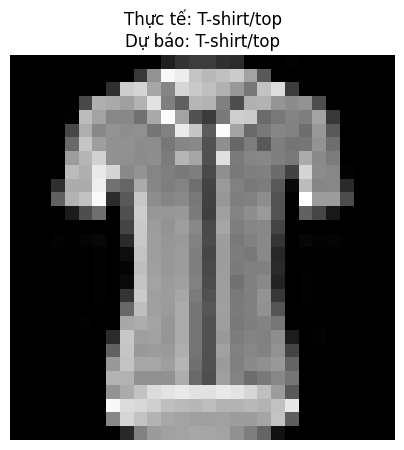

In [ ]:
import matplotlib.pyplot as plt

# Quick test for Exercise 3: Fashion-MNIST
fashion_labels = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
idx = np.random.randint(0, len(x_test_f))
sample = x_test_f[idx]
pred = model_f.predict(sample.reshape(1, 28, 28))

plt.imshow(sample, cmap='gray')
plt.title(f"True: {fashion_labels[y_test_f[idx]]} | Pred: {fashion_labels[np.argmax(pred)]}")
plt.axis('off')
plt.show()

In [ ]:
# Exercise 5: Text Generation (Truyện Kiều - Snippet Demo)
print("\n--- Exercise 5: Text Generation (Snippet) ---")
text_kieu = "Trăm năm trong cõi người ta, Chữ tài chữ mệnh khéo là ghét nhau. Trải qua một cuộc bể dâu, Những điều trông thấy mà đau đớn lòng."
chars = sorted(list(set(text_kieu)))
char_indices = dict((c, i) for i, c in enumerate(chars))

maxlen = 20
step = 3
sentences = []
next_chars = []
for i in range(0, len(text_kieu) - maxlen, step):
    sentences.append(text_kieu[i: i + maxlen])
    next_chars.append(text_kieu[i + maxlen])

x_gen = np.zeros((len(sentences), maxlen, len(chars)), dtype=bool)
y_gen = np.zeros((len(sentences), len(chars)), dtype=bool)
for i, sentence in enumerate(sentences):
    for t, char in enumerate(sentence):
        x_gen[i, t, char_indices[char]] = 1
    y_gen[i, char_indices[next_chars[i]]] = 1

model_gen = models.Sequential([
    layers.LSTM(128, input_shape=(maxlen, len(chars))),
    layers.Dense(len(chars), activation='softmax')
])

model_gen.compile(loss='categorical_crossentropy', optimizer='adam')
model_gen.fit(x_gen, y_gen, epochs=10, verbose=0)
print("Completed demo for Exercise 5.")


--- Exercise 5: Text Generation (Snippet) ---
Completed demo for Exercise 5.


In [ ]:
%%capture
!pip install flask flask-ngrok

In [ ]:
from flask import Flask, request, jsonify
import numpy as np

app = Flask(__name__)

@app.route('/')
def home():
    return "LSTM Model Deployment Portal - Exercises 1-7"

@app.route('/predict_cifar', methods=['POST'])
def predict_cifar():
    # Endpoint for CIFAR-10 prediction
    data = request.get_json(force=True)
    img = np.array(data['image']).reshape((1, 32, 96))
    prediction = model.predict(img)
    return jsonify({"class": int(np.argmax(prediction))})

@app.route('/predict_fashion', methods=['POST'])
def predict_fashion():
    # Endpoint for Fashion-MNIST prediction
    data = request.get_json(force=True)
    img = np.array(data['image']).reshape((1, 28, 28))
    prediction = model_f.predict(img)
    return jsonify({"class": int(np.argmax(prediction))})

print("Flask application structure is ready. Use a tunnel tool like ngrok to expose the server for Exercise 7.")

Flask application structure is ready. Use a tunnel tool like ngrok to expose the server for Exercise 7.
